# Modeling

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import re
%matplotlib inline

### Machine Learning

In [1]:
df_train = pd.read_csv('./data/train_fe.csv')
df_train.head()

NameError: name 'pd' is not defined

In [537]:
features = ['Pclass', 'Sex', 'Age', 'FareLog', 'Embarked', 'Title', 'FamilySize', 'FamilyCategory', 'CabinGroup', 'FareBinned']
target = 'Survived'
X = df_train[features]
y = df_train[target]

In [538]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [539]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42) 

In [540]:
numerical_features = X_train.select_dtypes(include = ['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include = ['object', 'category']).columns.tolist()

In [541]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

In [542]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 42))
])

In [543]:
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

In [544]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [545]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)

In [443]:
model.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 5, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [444]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



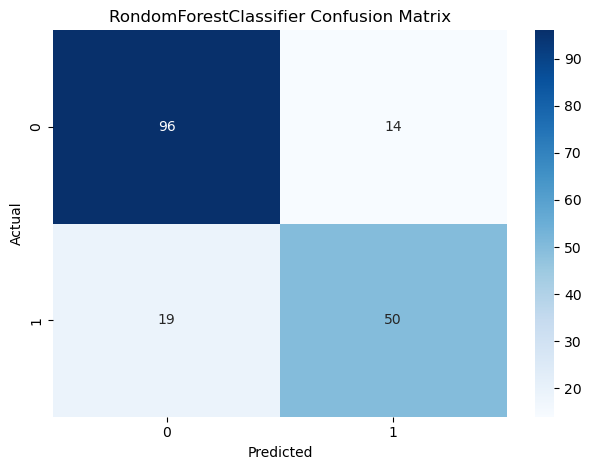

In [446]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('RondomForestClassifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [447]:
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .get_feature_names_out(categorical_features))

In [448]:
importance_df = pd.DataFrame({
    'Features' : feature_names,
    'Importance' : model.best_estimator_['classifier'].feature_importances_
}).sort_values(by = 'Importance')

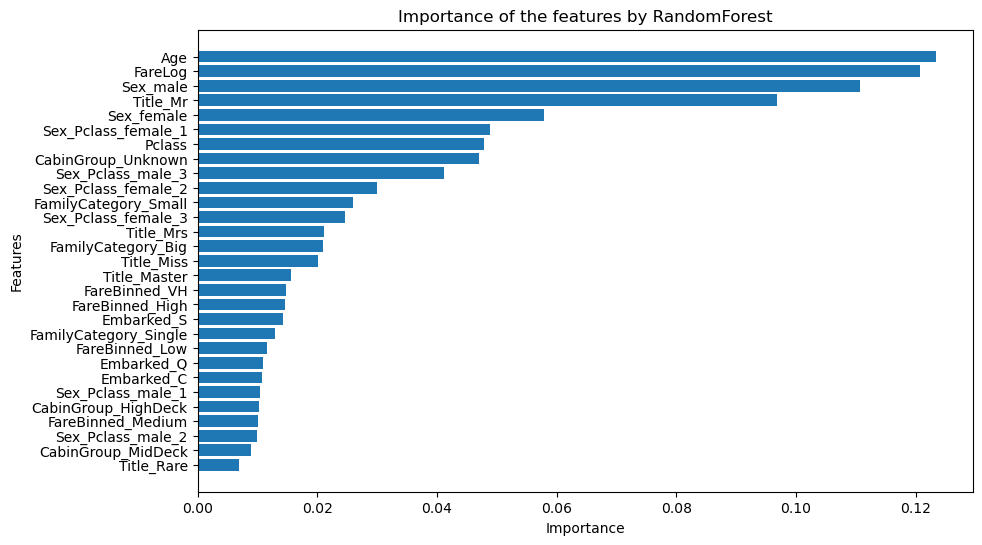

In [449]:
plt.figure(figsize = (10, 6))
plt.barh(importance_df['Features'], importance_df['Importance'])
plt.title('Importance of the features by RandomForest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [549]:
pipeline.set_params(classifier = LogisticRegression(random_state = 42))
model.estimator = pipeline
param_grid = [
    {
        'classifier__C': [0.01, 0.1, 1, 5], 
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'liblinear'],
        'classifier__max_iter': [500, 1000] 
    },
    {
        'classifier__C': [0.01, 0.1, 1, 5],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [500, 1000] 
    }
]
model.param_grid = param_grid
model.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.1s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.01, classifier__max_iter=500, classif

C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=5, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=5, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=5, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.1s
[CV] END classifier__C=5, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.1s
[CV] END classifier__C=5, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=5, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=5, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=5, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classif

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.01, 0.1, ...], 'classifier__max_iter': [500, 1000], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs', 'liblinear']}, {'classifier__C': [0.01, 0.1, ...], 'classifier__max_iter': [500, 1000], 'classifier__penalty': ['l1'], 'classifier__solver': ['liblinear', 'saga']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [550]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       110
           1       0.81      0.80      0.80        69

    accuracy                           0.85       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



In [552]:
lr_model = model.best_estimator_

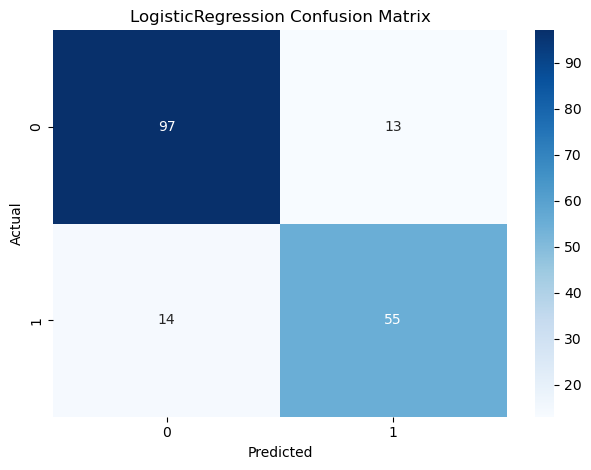

In [553]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('LogisticRegression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [554]:
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                                                .named_transformers_['cat']
                                                                .get_feature_names_out(categorical_features))
coefficient_df = pd.DataFrame({
    'Features' : feature_names,
    'Coefficient' : model.best_estimator_['classifier'].coef_[0]
}).sort_values(by = 'Coefficient')

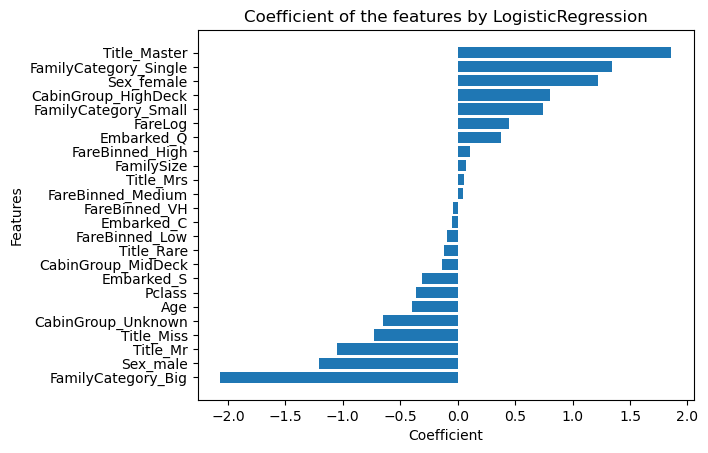

In [555]:
plt.figure()
plt.barh(coefficient_df['Features'], coefficient_df['Coefficient'])
plt.title('Coefficient of the features by LogisticRegression')
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.show()

In [566]:
pipeline.set_params(classifier = XGBClassifier(random_state = 42))
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__gamma': [0, 0.1] 
}
model.estimator = pipeline
model.param_grid = param_grid
model.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=100; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=2, classifier__n_estimators=100; total time

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__gamma': [0, 0.1], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [567]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       110
           1       0.79      0.75      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



In [568]:
xgb_model = model.best_estimator_

In [577]:
estimators = [
    ('lr', lr_model),
    ('xgb', xgb_model)
]
soft_voting_clf = VotingClassifier(
    estimators = estimators,
    voting = 'soft',
    weights = [0.65, 0.35],
    n_jobs = -1
)
soft_voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('xgb', ...)]"
,voting,'soft'
,weights,"[0.65, 0.35]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [578]:
y_pred = soft_voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       110
           1       0.80      0.80      0.80        69

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



### Model Evaluation

In [420]:
df_test = pd.read_csv('./data/test_fe.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


In [581]:
features = ['Pclass', 'Sex', 'Age', 'FareLog', 'Embarked', 'Title', 'FamilySize', 'FamilyCategory', 'CabinGroup', 'FareBinned']
X = df_test[features]

In [586]:
final_y_pred = soft_voting_clf.predict(X)

In [587]:
submission_df = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': final_y_pred
})

submission_df.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [588]:
submission_df.to_csv('submission.csv', index=False)